### Data Cleaning and Pre-processing

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("cardio_train.csv\cardio_train.csv", sep=';')

In [4]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [5]:
print(df.head())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [6]:
print("\nShape:")
print(df.shape)


Shape:
(70000, 13)


In [7]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


In [8]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


In [10]:
print(df.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [11]:
print("Duplicate Rows =", df.duplicated().sum())

Duplicate Rows = 0


In [12]:
print(df.dtypes)

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


In [13]:
df["age"]=(df["age"]/365).astype(int)
df["age"]

0        50
1        55
2        51
3        48
4        47
         ..
69995    52
69996    61
69997    52
69998    61
69999    56
Name: age, Length: 70000, dtype: int64

In [14]:
df["gender"]

0        2
1        1
2        1
3        2
4        1
        ..
69995    2
69996    1
69997    2
69998    1
69999    1
Name: gender, Length: 70000, dtype: int64

In [15]:
print(df.columns)

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')


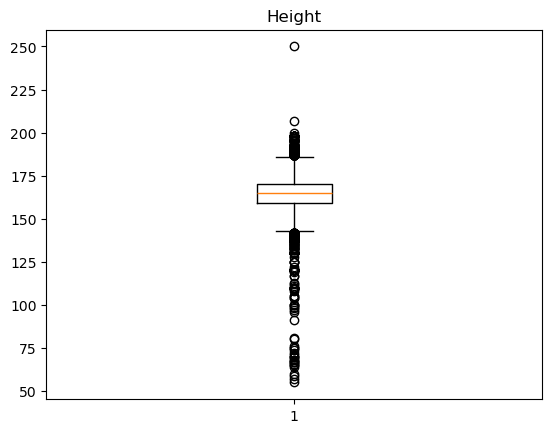

In [16]:
plt.boxplot(x=df["height"])
plt.title("Height")
plt.show()

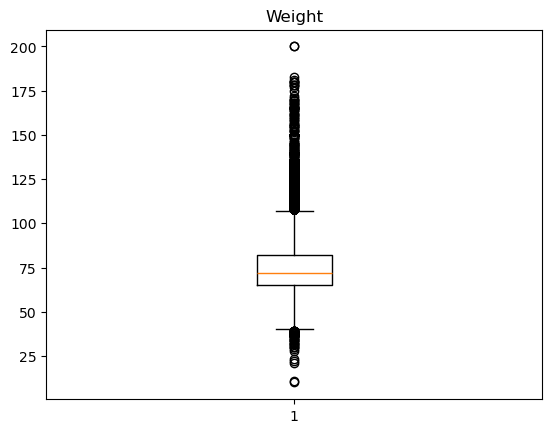

In [17]:
plt.boxplot(x=df["weight"])
plt.title("Weight")
plt.show()

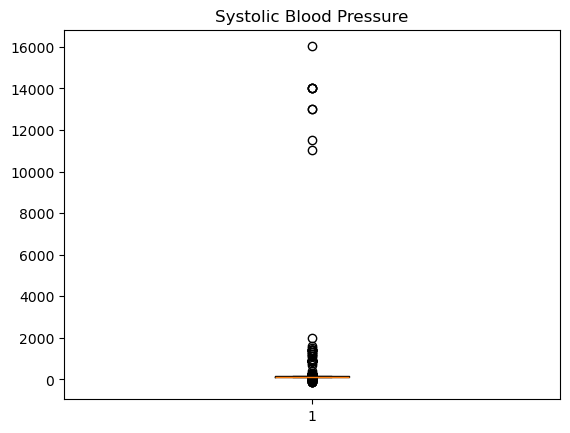

In [18]:
plt.boxplot(x=df["ap_hi"])
plt.title("Systolic Blood Pressure")
plt.show()

In [47]:
numeric_cols = ["height", "weight", "ap_hi", "ap_lo"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [48]:
df = df[df["ap_hi"] > df["ap_lo"]]

In [49]:
df["height"]

0        168
1        156
2        165
3        169
5        151
        ... 
69993    172
69994    165
69995    168
69998    163
69999    170
Name: height, Length: 61746, dtype: int64

In [50]:
df["weight"]

0        62.0
1        85.0
2        64.0
3        82.0
5        67.0
         ... 
69993    70.0
69994    80.0
69995    76.0
69998    72.0
69999    72.0
Name: weight, Length: 61746, dtype: float64

In [51]:
df["ap_hi"]

0        110
1        140
2        130
3        150
5        120
        ... 
69993    130
69994    150
69995    120
69998    135
69999    120
Name: ap_hi, Length: 61746, dtype: int64

In [52]:
df["ap_lo"]

0         80
1         90
2         70
3        100
5         80
        ... 
69993     90
69994     80
69995     80
69998     80
69999     80
Name: ap_lo, Length: 61746, dtype: int64

In [53]:
df=df[df["ap_hi"]>0]
df=df[df["ap_lo"]>0]
df=df[df["ap_hi"]>=df["ap_lo"]]

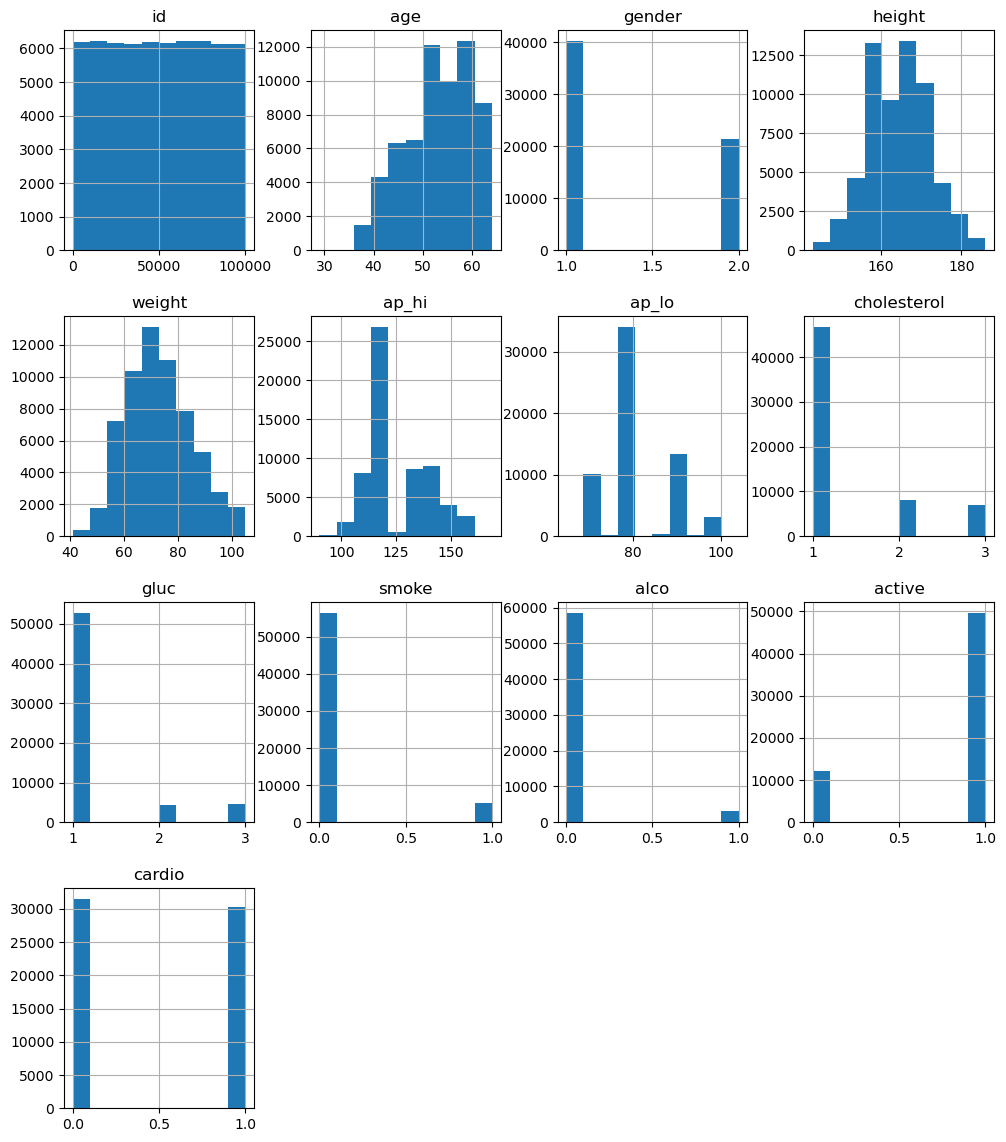

In [54]:
numeric=df.select_dtypes(include=np.number)
numeric.hist(figsize=(12,14))

plt.show()

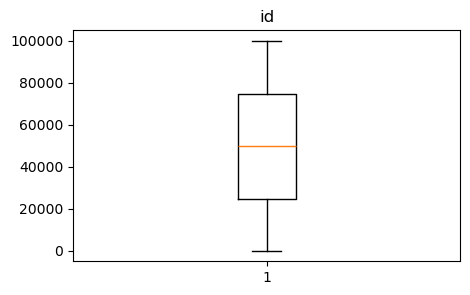

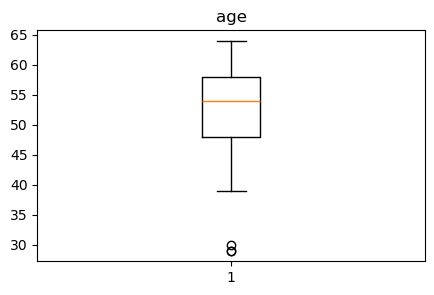

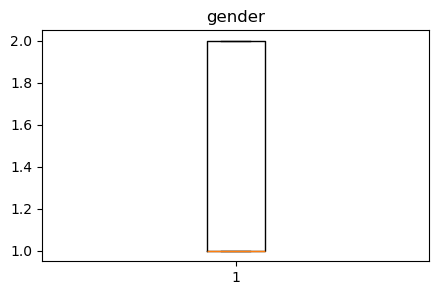

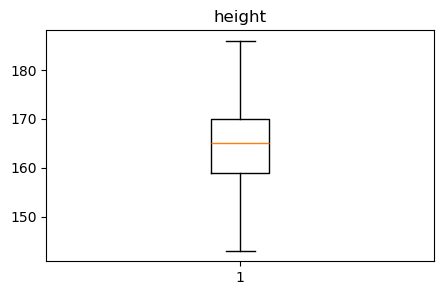

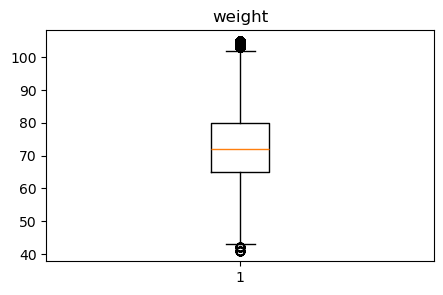

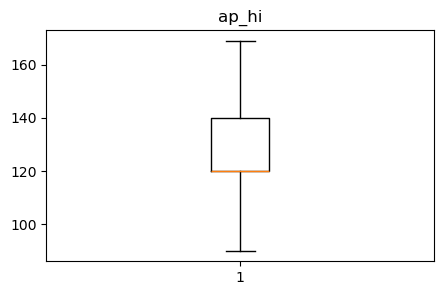

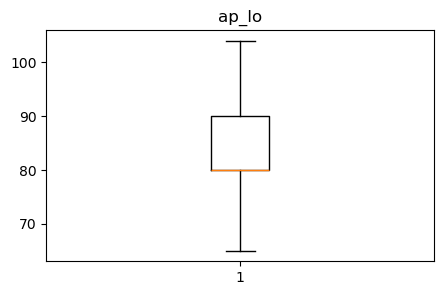

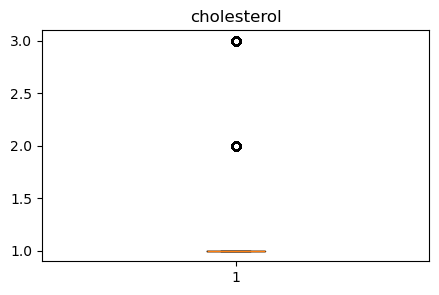

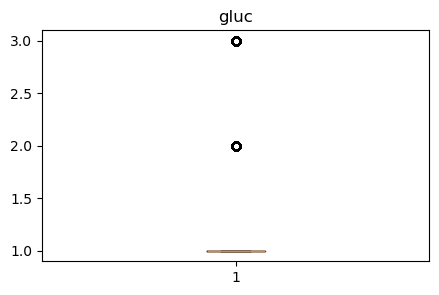

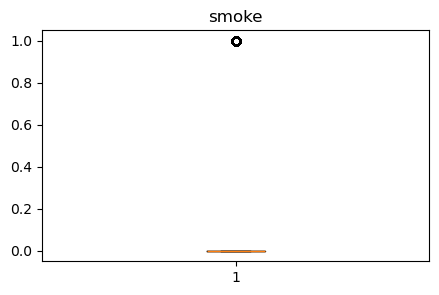

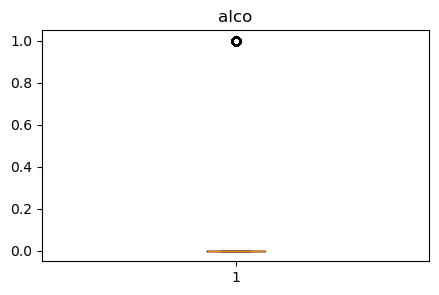

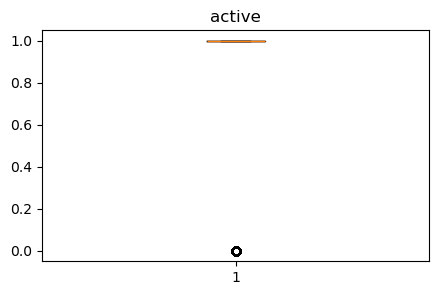

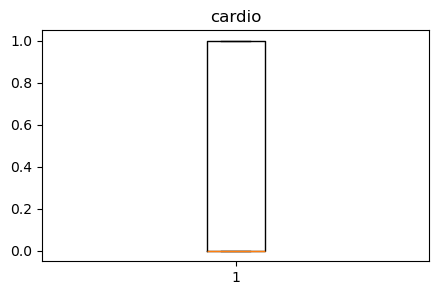

In [55]:
for col in numeric.columns:
    plt.figure(figsize=(5,3))
    plt.boxplot(x=df[col])
    plt.title(col)
    plt.show()

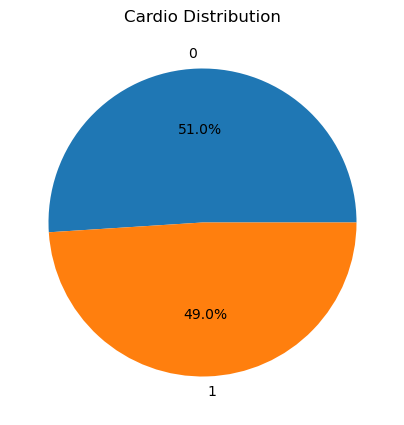

In [61]:
df["cardio"].value_counts().plot(

kind="pie",

autopct="%1.1f%%",

figsize=(5,5)

)

plt.ylabel("")

plt.title("Cardio Distribution")

plt.show()